# 🚢 APL Logistics — Customer, Product & Profitability Analysis


## ⚙️ Cell 1 — Install Libraries

In [ ]:
!pip install -q plotly kaleido
print("✅ Done")

✅ Done


## 📦 Cell 2 — Import All Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "axes.grid": True,
    "grid.alpha": 0.4,
    "font.size": 11
})
PALETTE = ["#1a6faf", "#22c55e", "#ef4444", "#f59e0b", "#7c3aed", "#0891b2"]
print("✅ All libraries imported successfully")

✅ All libraries imported successfully


## 📁 Cell 3 — Mount Google Drive & Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

FILE_PATH = '/content/drive/MyDrive/APL_Logistics.csv'

df = pd.read_csv(FILE_PATH, encoding='latin1', low_memory=False)
print(f"✅ Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Data loaded: 180,519 rows × 40 columns


## 🔍 Cell 4 — Data Overview

In [ ]:
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Shape : {df.shape}")
print(f"Columns: {df.shape[1]}")
print()
print("── Column Data Types ──")
print(df.dtypes)
print()
print("── Missing Values ──")
missing = df.isnull().sum()
print(missing[missing > 0] if missing[missing > 0].any() else "No missing values found ✅")
print()
display(df.head(3))

DATASET OVERVIEW
Shape : (180519, 40)
Columns: 40

── Column Data Types ──
Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                 float64
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude                        float64
Market                 

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,...,5,499.95,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,...,5,199.95,167.96,48.71,Central America,Cortés,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,...,1,199.99,181.99,87.36,Central America,Cortés,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class


## 🧹 Cell 5 — Data Cleaning & Feature Engineering

In [ ]:
print("=" * 55)
print("STEP: DATA CLEANING & FINANCIAL VALIDATION")
print("=" * 55)

# Coerce numeric columns
num_cols = [
    'Benefit per order', 'Sales per customer', 'Order Item Discount',
    'Order Item Discount Rate', 'Order Item Product Price',
    'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
    'Order Item Total', 'Order Profit Per Order'
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Drop rows where both Sales and Profit are null
before = len(df)
df.dropna(subset=['Sales', 'Order Profit Per Order'], how='all', inplace=True)
print(f"Dropped {before - len(df)} invalid rows. Remaining: {len(df):,}")

# Derived columns
df['Profit Margin %']  = (df['Order Profit Per Order'] / df['Sales'].replace(0, np.nan)) * 100
df['Customer Name']    = df['Customer Fname'].astype(str) + ' ' + df['Customer Lname'].astype(str)
df['Is Loss Order']    = (df['Order Profit Per Order'] < 0).astype(int)
df['Discount Bracket'] = pd.cut(
    df['Order Item Discount Rate'],
    bins=[-0.01, 0.0, 0.05, 0.10, 0.15, 0.20, 0.30, 1.0],
    labels=['0%', '1-5%', '5-10%', '10-15%', '15-20%', '20-30%', '30%+']
)

print("\n✅ Derived columns added:")
print("   Profit Margin % | Customer Name | Is Loss Order | Discount Bracket")
display(df[['Sales', 'Order Profit Per Order', 'Profit Margin %', 'Is Loss Order', 'Discount Bracket']].head())

STEP: DATA CLEANING & FINANCIAL VALIDATION
Dropped 0 invalid rows. Remaining: 180,519

✅ Derived columns added:
   Profit Margin % | Customer Name | Is Loss Order | Discount Bracket


,Sales,Order Profit Per Order,Profit Margin %,Is Loss Order,Discount Bracket
0,499.95,159.69,31.941194,0,5-10%
1,199.95,48.71,24.361090,0,15-20%
2,199.99,87.36,43.682184,0,5-10%
3,199.99,-41.89,-20.946047,1,10-15%
4,50.00,10.00,20.000000,0,15-20%


## 📊 Cell 6 — KPI Summary

In [ ]:
total_revenue = df['Sales'].sum()
total_profit  = df['Order Profit Per Order'].sum()
total_orders  = len(df)
avg_margin    = (total_profit / total_revenue) * 100
loss_orders   = df['Is Loss Order'].sum()
loss_pct      = loss_orders / total_orders * 100
avg_order_val = total_revenue / total_orders
unique_custs  = df['Customer Id'].nunique()

print("=" * 50)
print("        KEY PERFORMANCE INDICATORS")
print("=" * 50)
print(f"  Total Revenue         : ${total_revenue:>15,.2f}")
print(f"  Total Profit          : ${total_profit:>15,.2f}")
print(f"  Profit Margin         : {avg_margin:>15.2f} %")
print(f"  Total Orders          : {total_orders:>15,}")
print(f"  Avg Order Value       : ${avg_order_val:>15,.2f}")
print(f"  Loss-Making Orders    : {loss_orders:>15,}  ({loss_pct:.1f}%)")
print(f"  Unique Customers      : {unique_custs:>15,}")
print(f"  Avg Discount Rate     : {df['Order Item Discount Rate'].mean()*100:>15.2f} %")
print(f"  Total Discount Given  : ${df['Order Item Discount'].sum():>15,.2f}")
print("=" * 50)

        KEY PERFORMANCE INDICATORS
  Total Revenue         : $  36,784,734.31
  Total Profit          : $   3,966,902.97
  Profit Margin         :           10.78 %
  Total Orders          :         180,519
  Avg Order Value       : $         203.77
  Loss-Making Orders    :          33,784  (18.7%)
  Unique Customers      :          20,652
  Avg Discount Rate     :           10.17 %
  Total Discount Given  : $   3,730,378.40


## 📈 Cell 7 — Revenue & Profit by Customer Segment

                      Revenue      Profit  Orders  Margin
Customer Segment                                         
Consumer          19095789.79  2073487.67   93504    10.9
Corporate         11168406.63  1202574.96   54789    10.8
Home Office        6520537.89   690840.34   32226    10.6


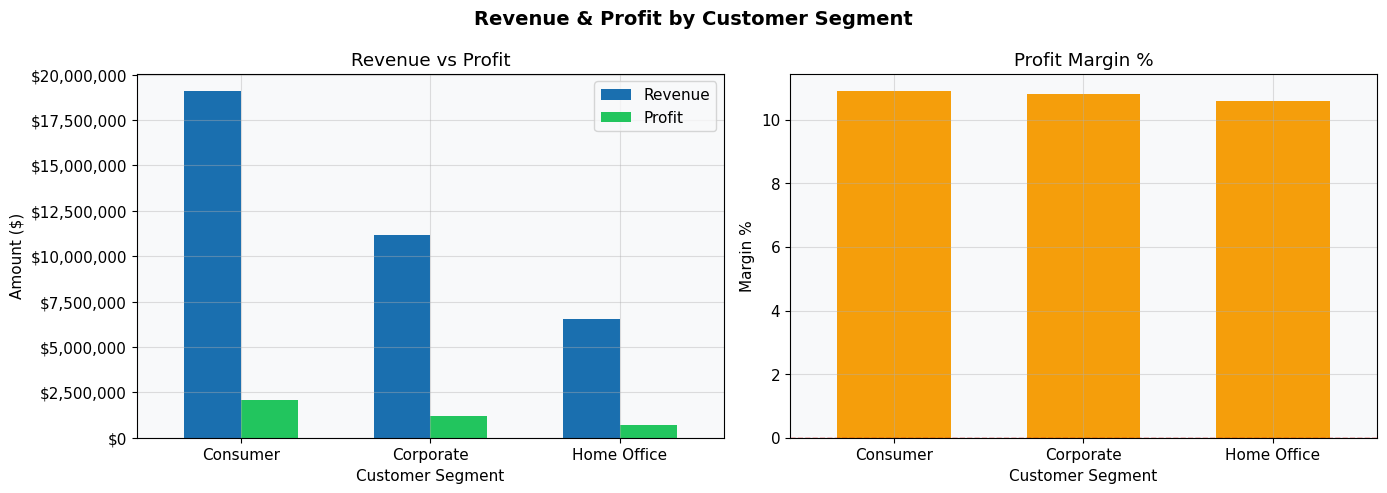

📊 Saved: chart_01_segment.png


In [ ]:
seg = df.groupby('Customer Segment').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Order Profit Per Order', 'sum'),
    Orders=('Sales', 'count')
).assign(Margin=lambda x: (x['Profit'] / x['Revenue'] * 100).round(1))

print(seg.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Revenue & Profit by Customer Segment', fontsize=14, fontweight='bold')

seg[['Revenue', 'Profit']].plot(kind='bar', ax=axes[0],
    color=['#1a6faf', '#22c55e'], edgecolor='none', width=0.6)
axes[0].set_title('Revenue vs Profit')
axes[0].set_ylabel('Amount ($)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

seg['Margin'].plot(kind='bar', ax=axes[1], color='#f59e0b', edgecolor='none', width=0.6)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Profit Margin %')
axes[1].set_ylabel('Margin %')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('chart_01_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved: chart_01_segment.png')

## 📉 Cell 8 — Profit Distribution Histogram

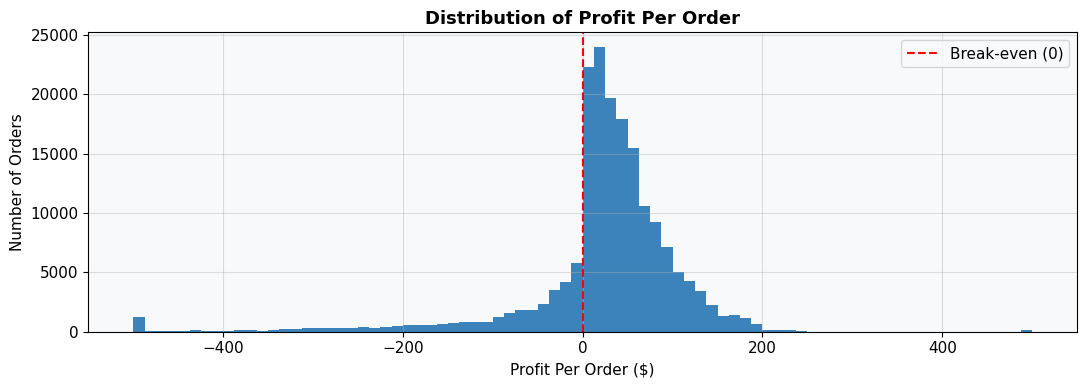

Orders with profit > 0  : 145,558
Orders with profit = 0  : 1,177
Orders with profit < 0  : 33,784  ← Loss orders
📊 Saved: chart_02_profit_dist.png


In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(df['Order Profit Per Order'].clip(-500, 500), bins=80,
        color='#1a6faf', edgecolor='none', alpha=0.85)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Break-even (0)')
ax.set_title('Distribution of Profit Per Order', fontsize=13, fontweight='bold')
ax.set_xlabel('Profit Per Order ($)')
ax.set_ylabel('Number of Orders')
ax.legend()
plt.tight_layout()
plt.savefig('chart_02_profit_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Orders with profit > 0  : {(df['Order Profit Per Order'] > 0).sum():,}")
print(f"Orders with profit = 0  : {(df['Order Profit Per Order'] == 0).sum():,}")
print(f"Orders with profit < 0  : {(df['Order Profit Per Order'] < 0).sum():,}  ← Loss orders")
print('📊 Saved: chart_02_profit_dist.png')

## 📦 Cell 9 — Category-Level Profitability

--- Category Profitability ---
                         Revenue     Profit  Orders  Avg_Discount  Margin
Category Name                                                            
Strength Training       54895.53     332.31     111          0.11     0.6
CDs                      3059.59     383.85     271          0.10    12.5
As Seen on  TV!         20597.94     714.43      68          0.11     3.5
Books                   12587.40     883.01     405          0.10     7.0
Toys                     6104.66     900.71     529          0.10    14.8
Baby                    12229.56    1525.03     207          0.10    12.5
Golf Bags & Carts       10369.39    1810.07      61          0.09    17.5
Basketball              27099.33    1845.67      67          0.10     6.8
Men's Clothing          43856.80    2006.04     208          0.10     4.6
Video Games             33310.50    2717.52     838          0.10     8.2
Golf Apparel            34969.75    3496.31     441          0.10    10.0
Pet Sup

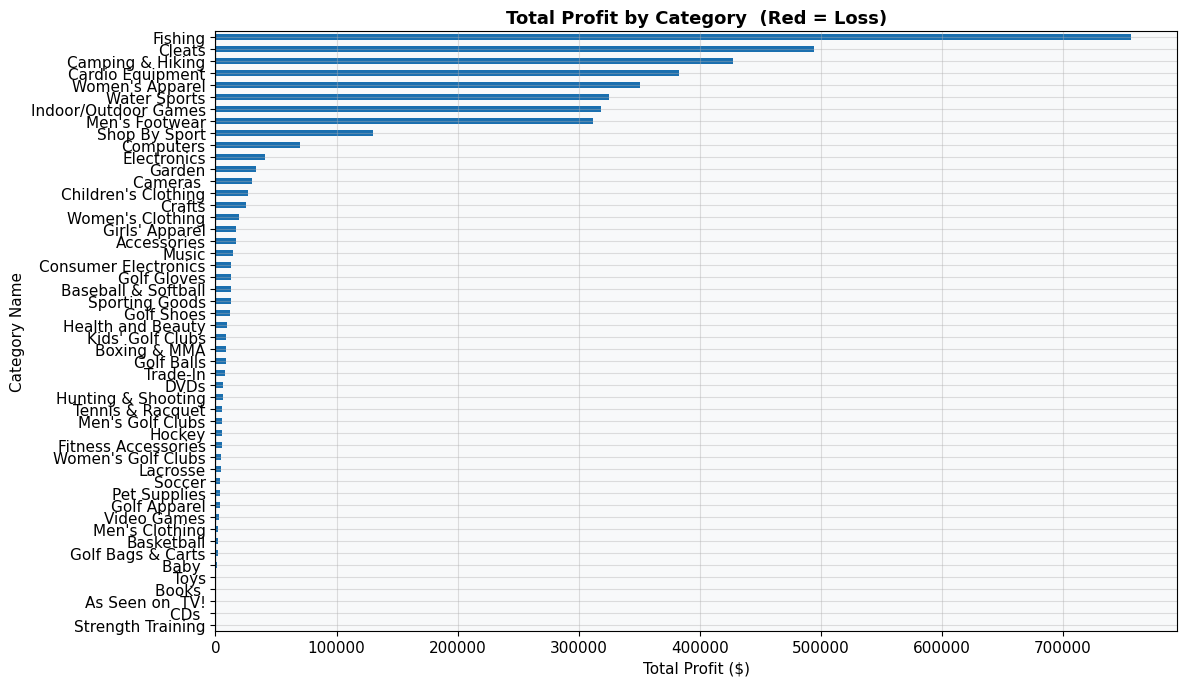

📊 Saved: chart_03_category_profit.png


In [ ]:
cat_grp = df.groupby('Category Name').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Order Profit Per Order', 'sum'),
    Orders=('Sales', 'count'),
    Avg_Discount=('Order Item Discount Rate', 'mean')
).assign(Margin=lambda x: (x['Profit'] / x['Revenue'] * 100).round(1)).sort_values('Profit')

print('--- Category Profitability ---')
print(cat_grp.round(2))

loss_cats = cat_grp[cat_grp['Profit'] < 0]
if not loss_cats.empty:
    print(f"\n⚠️ Loss-Making Categories ({len(loss_cats)}):")
    print(loss_cats[['Revenue', 'Profit', 'Margin']])
else:
    print("\n✅ No loss-making categories.")

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#ef4444' if p < 0 else '#1a6faf' for p in cat_grp['Profit']]
cat_grp['Profit'].plot(kind='barh', ax=ax, color=colors, edgecolor='none')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Total Profit by Category  (Red = Loss)', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Profit ($)')
plt.tight_layout()
plt.savefig('chart_03_category_profit.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved: chart_03_category_profit.png')

## 🔥 Cell 10 — Category × Segment Profit Heatmap

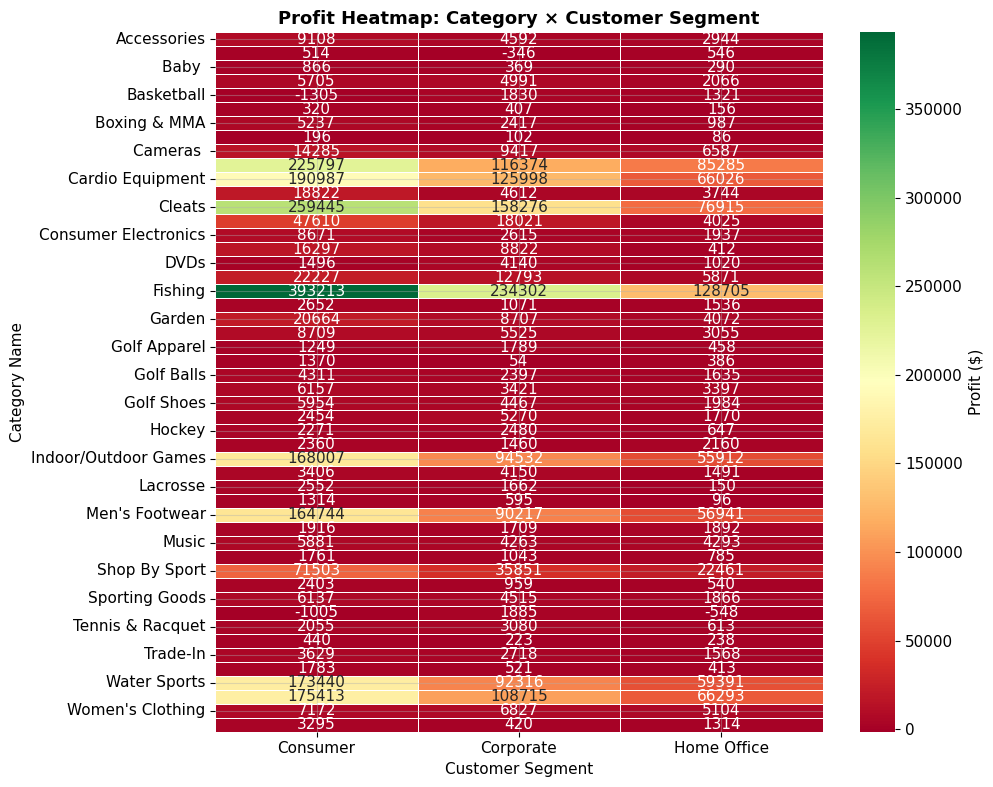

📊 Saved: chart_04_heatmap_cat_seg.png


In [ ]:
heat = df.pivot_table(index='Category Name', columns='Customer Segment',
                      values='Order Profit Per Order', aggfunc='sum')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heat, cmap='RdYlGn', annot=True, fmt='.0f',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Profit ($)'})
ax.set_title('Profit Heatmap: Category × Customer Segment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_04_heatmap_cat_seg.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved: chart_04_heatmap_cat_seg.png')

## 🏆 Cell 11 — Top & Bottom Products

--- Top 10 Most Profitable Products ---
                                                  Revenue     Profit  Margin
Product Name                                                                
Field & Stream Sportsman 16 Gun Fire Safe      6929653.50  756220.76    10.9
Perfect Fitness Perfect Rip Deck               4421143.02  493828.30    11.2
Diamondback Women's Serene Classic Comfort Bi  4118425.42  427455.57    10.4
Nike Men's Free 5.0+ Running Shoe              3667633.20  379915.82    10.4
Nike Men's Dri-FIT Victory Golf Polo           3147800.00  350421.03    11.1
Pelican Sunstream 100 Kayak                    3099845.00  324076.37    10.5
O'Brien Men's Neoprene Life Vest               2888993.94  318451.43    11.0
Nike Men's CJ Elite 2 TD Football Cleat        2891757.54  311902.82    10.8
Under Armour Girls' Toddler Spine Surge Runni  1269082.65  126278.51    10.0
Dell Laptop                                     663000.00   69656.81    10.5

--- Top 10 Loss-Making Products ---

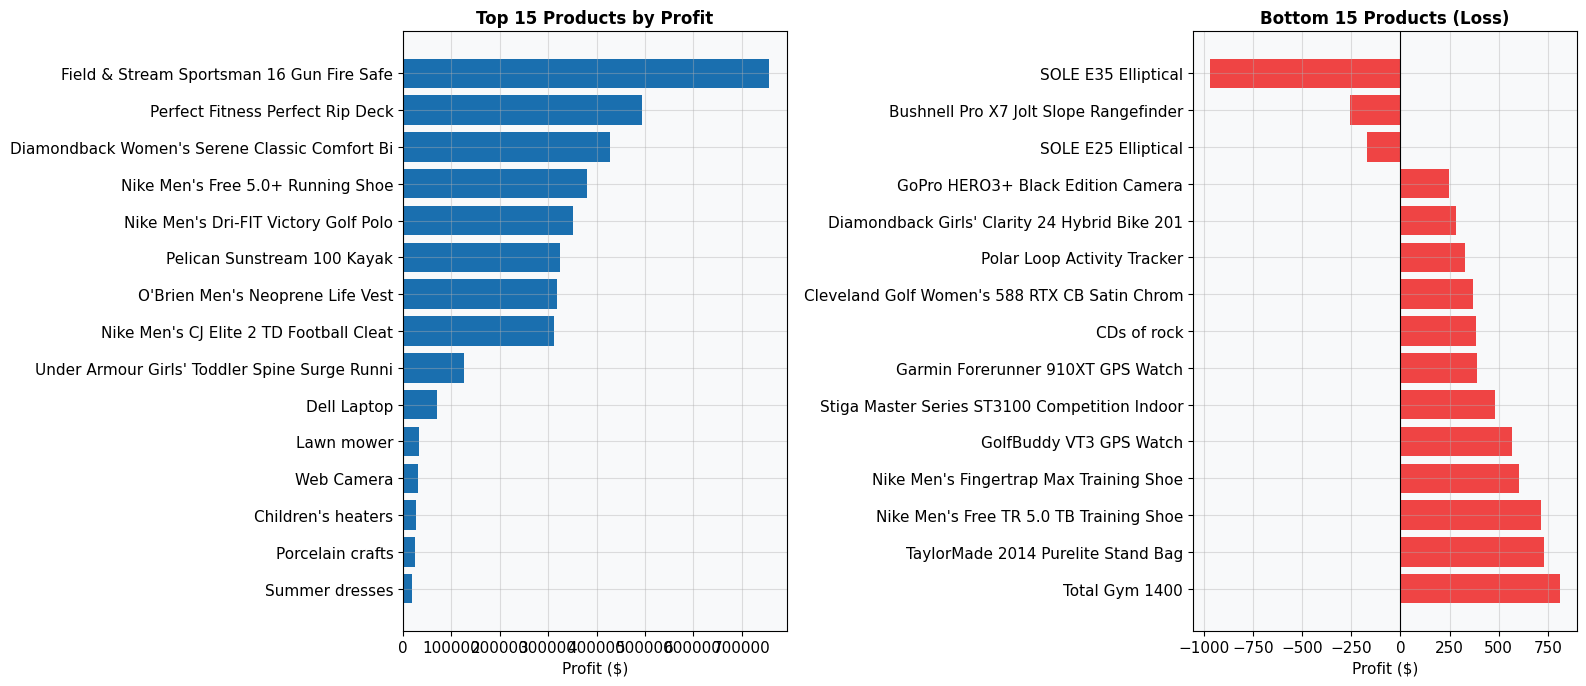

📊 Saved: chart_05_products.png


In [ ]:
prod_grp = df.groupby('Product Name').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Order Profit Per Order', 'sum'),
    Orders=('Sales', 'count')
).assign(Margin=lambda x: (x['Profit'] / x['Revenue'] * 100).round(1))

top15  = prod_grp.nlargest(15, 'Profit')
bot15  = prod_grp.nsmallest(15, 'Profit')
risky  = prod_grp[
    (prod_grp['Revenue'] > prod_grp['Revenue'].quantile(0.5)) &
    (prod_grp['Margin'] < 10)
].nlargest(10, 'Revenue')

print('--- Top 10 Most Profitable Products ---')
print(top15.head(10)[['Revenue', 'Profit', 'Margin']])

print('\n--- Top 10 Loss-Making Products ---')
print(bot15.head(10)[['Revenue', 'Profit', 'Margin']])

print('\n--- ⚠️ High Revenue, Low Margin Products ---')
print(risky[['Revenue', 'Profit', 'Margin']])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(top15['Profit'].index, top15['Profit'].values, color='#1a6faf', edgecolor='none')
axes[0].set_title('Top 15 Products by Profit', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Profit ($)')
axes[0].invert_yaxis()

axes[1].barh(bot15['Profit'].index, bot15['Profit'].values, color='#ef4444', edgecolor='none')
axes[1].set_title('Bottom 15 Products (Loss)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Profit ($)')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('chart_05_products.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved: chart_05_products.png')

## 👥 Cell 12 — Customer Value Analysis

Total unique customers : 20,652
Avg profit per customer: $192.08
Loss-making customers  : 4,069

📌 Pareto: Top 20% customers → 79.2% of total profit


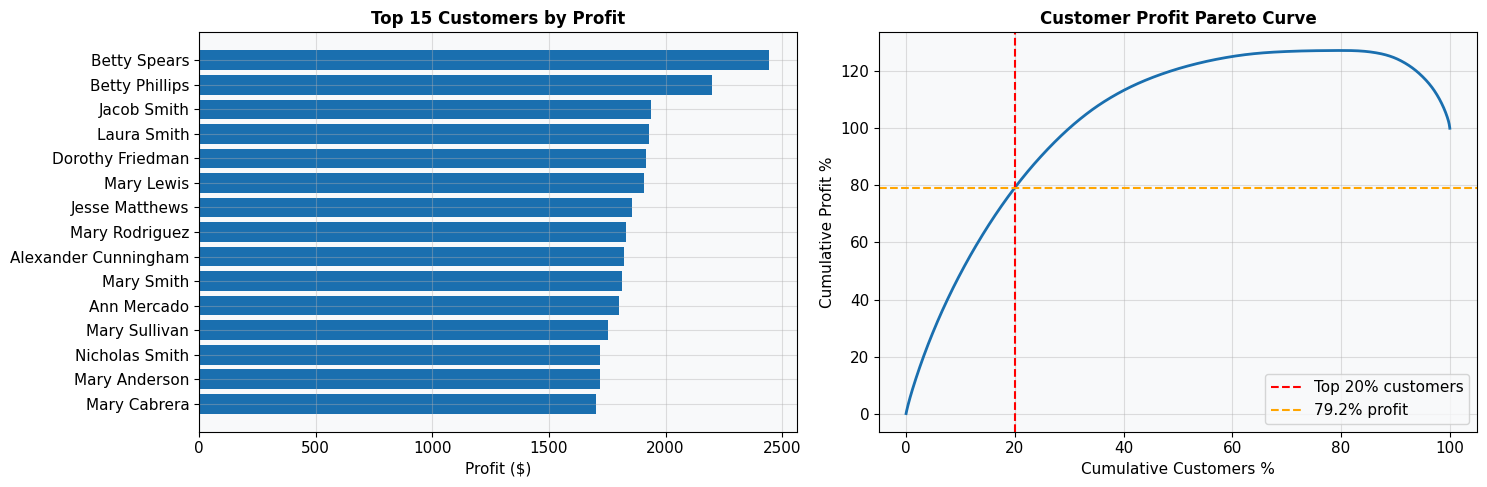

📊 Saved: chart_06_customer_value.png


In [ ]:
cust_grp = df.groupby(['Customer Id', 'Customer Name', 'Customer Segment']).agg(
    Revenue=('Sales', 'sum'),
    Profit=('Order Profit Per Order', 'sum'),
    Orders=('Sales', 'count')
).assign(Margin=lambda x: (x['Profit'] / x['Revenue'] * 100).round(1)).reset_index()

print(f"Total unique customers : {len(cust_grp):,}")
print(f"Avg profit per customer: ${cust_grp['Profit'].mean():,.2f}")
print(f"Loss-making customers  : {(cust_grp['Profit'] < 0).sum():,}")

# Pareto
cust_sorted = cust_grp.sort_values('Profit', ascending=False).reset_index(drop=True)
cust_sorted['Cum Profit %']   = cust_sorted['Profit'].cumsum() / cust_sorted['Profit'].sum() * 100
cust_sorted['Cum Customer %'] = np.arange(1, len(cust_sorted)+1) / len(cust_sorted) * 100
top20_pct = cust_sorted[cust_sorted['Cum Customer %'] <= 20]['Profit'].sum() / cust_sorted['Profit'].sum() * 100
print(f"\n📌 Pareto: Top 20% customers → {top20_pct:.1f}% of total profit")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top15c = cust_sorted.head(15)
axes[0].barh(top15c['Customer Name'], top15c['Profit'], color='#1a6faf', edgecolor='none')
axes[0].set_title('Top 15 Customers by Profit', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Profit ($)')
axes[0].invert_yaxis()

axes[1].plot(cust_sorted['Cum Customer %'], cust_sorted['Cum Profit %'], color='#1a6faf', linewidth=2)
axes[1].axvline(20, color='red', linestyle='--', label='Top 20% customers')
axes[1].axhline(top20_pct, color='orange', linestyle='--', label=f'{top20_pct:.1f}% profit')
axes[1].set_title('Customer Profit Pareto Curve', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cumulative Customers %')
axes[1].set_ylabel('Cumulative Profit %')
axes[1].legend()

plt.tight_layout()
plt.savefig('chart_06_customer_value.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved: chart_06_customer_value.png')

## 🏷️ Cell 13 — Discount Impact Analysis

--- Profitability by Discount Bracket ---
                  Avg_Margin  Avg_Profit_Ratio  Orders  Total_Profit  \
Discount Bracket                                                       
0%                     12.73              0.13   10028     267412.40   
1-5%                   11.72              0.12   50143    1171682.08   
5-10%                  11.28              0.12   40116     926511.63   
10-15%                 10.20              0.12   30087     625339.12   
15-20%                  9.60              0.12   40116     784061.02   
20-30%                  9.52              0.13   10029     191896.72   

                  Total_Discount  
Discount Bracket                  
0%                          0.00  
1-5%                   306523.06  
5-10%                  643742.60  
10-15%                 817610.24  
15-20%                1451398.93  
20-30%                 511103.57  

--- Correlation: Discount Rate vs Profit ---
                          Order Item Discount Rate  Ord

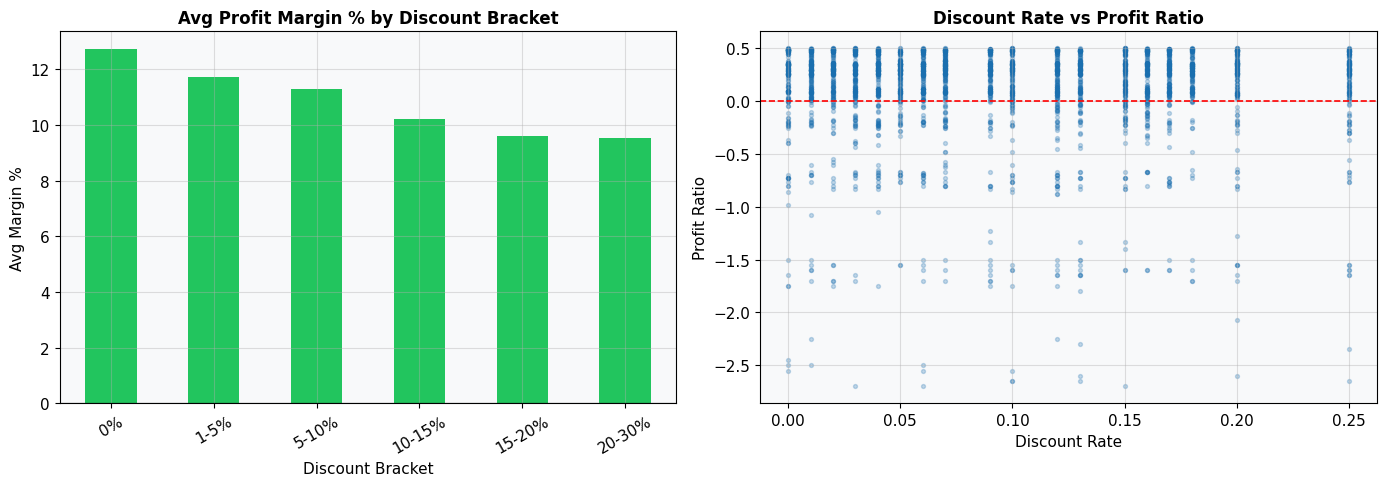

📊 Saved: chart_07_discount_impact.png


In [ ]:
disc_impact = df.groupby('Discount Bracket', observed=True).agg(
    Avg_Margin=('Profit Margin %', 'mean'),
    Avg_Profit_Ratio=('Order Item Profit Ratio', 'mean'),
    Orders=('Sales', 'count'),
    Total_Profit=('Order Profit Per Order', 'sum'),
    Total_Discount=('Order Item Discount', 'sum')
).round(2)

print('--- Profitability by Discount Bracket ---')
print(disc_impact)

corr = df[['Order Item Discount Rate', 'Order Item Profit Ratio',
           'Order Profit Per Order', 'Profit Margin %']].corr()
print('\n--- Correlation: Discount Rate vs Profit ---')
print(corr.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#ef4444' if v < 0 else '#22c55e' for v in disc_impact['Avg_Margin']]
disc_impact['Avg_Margin'].plot(kind='bar', ax=axes[0], color=colors, edgecolor='none')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Avg Profit Margin % by Discount Bracket', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Avg Margin %')
axes[0].tick_params(axis='x', rotation=30)

sample = df.sample(min(3000, len(df)), random_state=42)
axes[1].scatter(sample['Order Item Discount Rate'], sample['Order Item Profit Ratio'],
                alpha=0.25, color='#1a6faf', s=8)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.2)
axes[1].set_title('Discount Rate vs Profit Ratio', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Discount Rate')
axes[1].set_ylabel('Profit Ratio')

plt.tight_layout()
plt.savefig('chart_07_discount_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved: chart_07_discount_impact.png')

## 🌍 Cell 14 — Market & Regional Analysis

--- Market-Level Profitability ---
                  Revenue      Profit  Orders  Margin
Market                                               
Europe        10872396.60  1169442.96   50252    10.8
LATAM         10277612.64  1123321.61   51594    10.9
Pacific Asia   8273743.58   857753.44   41260    10.4
USCA           5066528.61   564313.78   25799    11.1
Africa         2294452.88   252071.18   11614    11.0

--- Top 10 Regions by Profit ---
                    Revenue     Profit  Orders  Margin
Order Region                                          
Western Europe   5894380.66  625446.08   27109    10.6
Central America  5665711.99  616341.57   28341    10.9
South America    2960881.35  335154.40   14935    11.3
Northern Europe  2155830.61  233450.60    9792    10.8
Southern Europe  2047918.78  230829.23    9431    11.3
Southeast Asia   1932495.53  211342.82    9539    10.9
Oceania          2016654.16  201478.02   10148    10.0
Caribbean        1651019.30  171825.64    8318    10.4
Sou

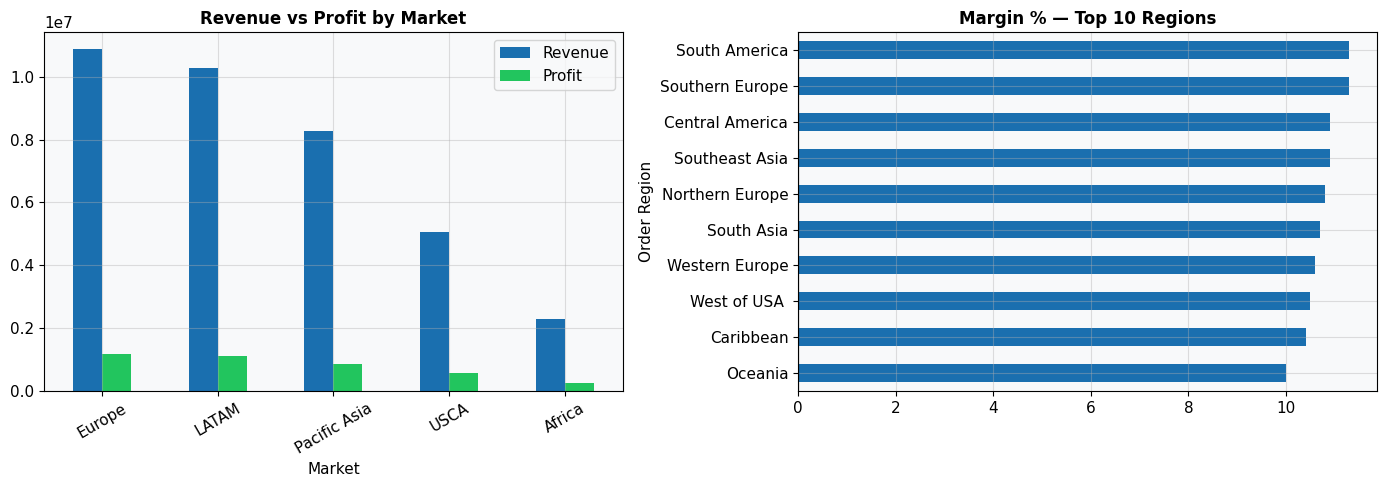

📊 Saved: chart_08_market_region.png


In [ ]:
market_grp = df.groupby('Market').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Order Profit Per Order', 'sum'),
    Orders=('Sales', 'count')
).assign(Margin=lambda x: (x['Profit'] / x['Revenue'] * 100).round(1)).sort_values('Profit', ascending=False)

region_grp = df.groupby('Order Region').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Order Profit Per Order', 'sum'),
    Orders=('Sales', 'count')
).assign(Margin=lambda x: (x['Profit'] / x['Revenue'] * 100).round(1)).sort_values('Profit', ascending=False)

print('--- Market-Level Profitability ---')
print(market_grp.round(2))

print('\n--- Top 10 Regions by Profit ---')
print(region_grp.head(10).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

market_grp[['Revenue', 'Profit']].plot(kind='bar', ax=axes[0],
    color=['#1a6faf', '#22c55e'], edgecolor='none')
axes[0].set_title('Revenue vs Profit by Market', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

top_reg = region_grp.head(10)['Margin'].sort_values()
bar_colors = ['#ef4444' if v < 0 else '#1a6faf' for v in top_reg]
top_reg.plot(kind='barh', ax=axes[1], color=bar_colors, edgecolor='none')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Margin % — Top 10 Regions', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('chart_08_market_region.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved: chart_08_market_region.png')

## 🗺️ Cell 15 — Region × Category Heatmap

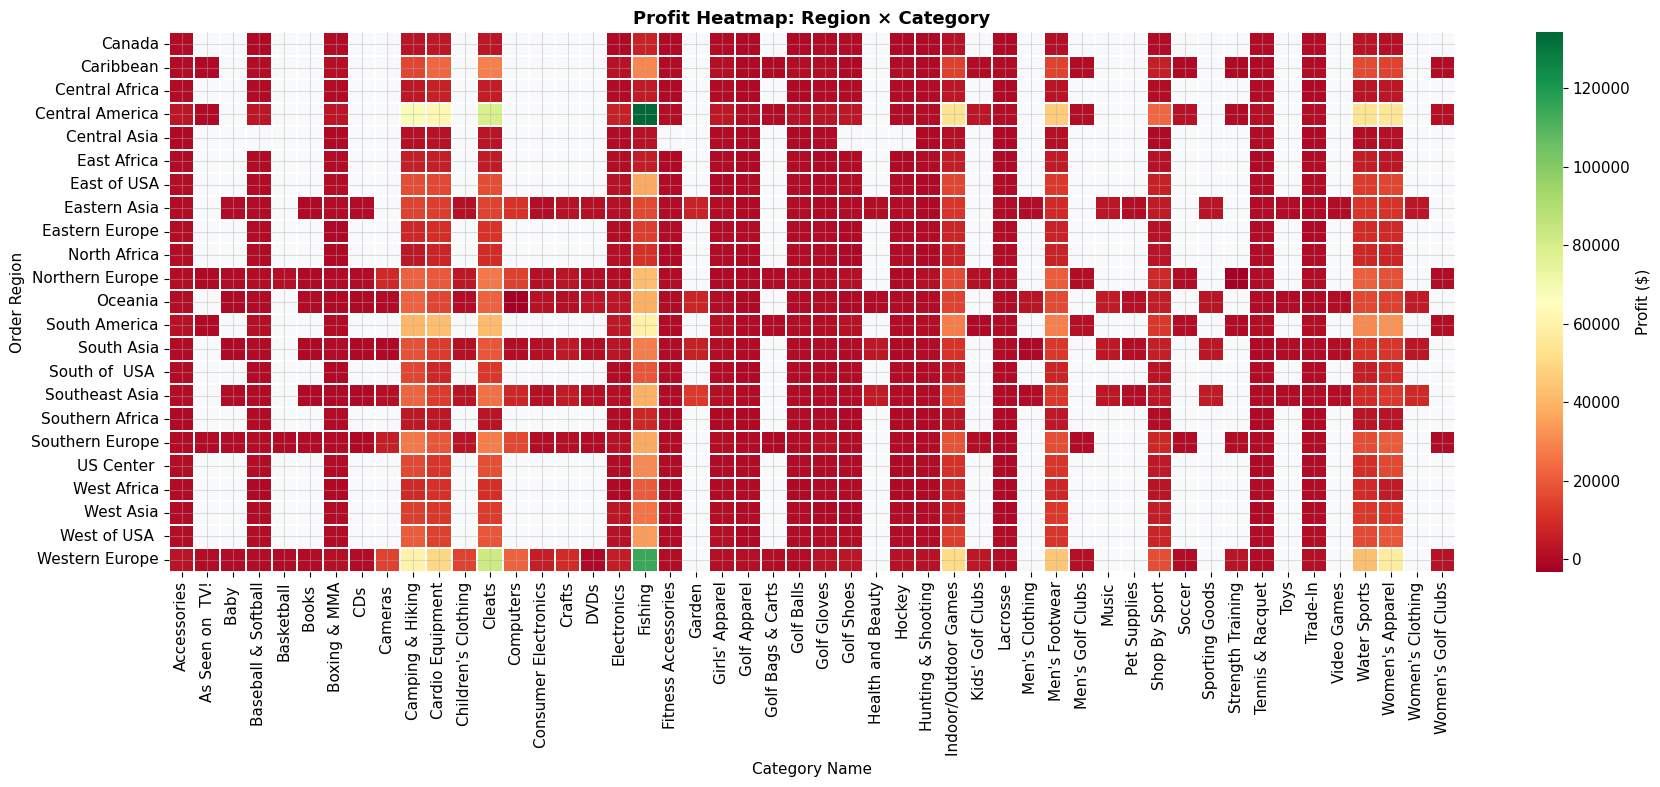

📊 Saved: chart_09_region_category_heatmap.png


In [ ]:
rc_heat = df.pivot_table(index='Order Region', columns='Category Name',
                          values='Order Profit Per Order', aggfunc='sum')

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(rc_heat, cmap='RdYlGn', annot=False, linewidths=0.3,
            ax=ax, cbar_kws={'label': 'Profit ($)'})
ax.set_title('Profit Heatmap: Region × Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_09_region_category_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved: chart_09_region_category_heatmap.png')

## 💾 Cell 16 — Export All Summary CSVs

In [ ]:
cat_grp.reset_index().to_csv('category_profitability.csv', index=False)
prod_grp.reset_index().to_csv('product_profitability.csv', index=False)
cust_grp.to_csv('customer_profitability.csv', index=False)
market_grp.reset_index().to_csv('market_profitability.csv', index=False)
region_grp.reset_index().to_csv('region_profitability.csv', index=False)
disc_impact.reset_index().to_csv('discount_impact.csv', index=False)

# KPI summary
kpi_df = pd.DataFrame({
    'KPI': [
        'Total Revenue ($)', 'Total Profit ($)', 'Profit Margin (%)',
        'Total Orders', 'Avg Order Value ($)', 'Loss-Making Orders',
        'Loss-Making Orders (%)', 'Unique Customers',
        'Total Discount Given ($)', 'Avg Discount Rate (%)'
    ],
    'Value': [
        f"${df['Sales'].sum():,.2f}",
        f"${df['Order Profit Per Order'].sum():,.2f}",
        f"{df['Order Profit Per Order'].sum()/df['Sales'].sum()*100:.2f}%",
        f"{len(df):,}",
        f"${df['Sales'].sum()/len(df):,.2f}",
        f"{df['Is Loss Order'].sum():,}",
        f"{df['Is Loss Order'].mean()*100:.1f}%",
        f"{df['Customer Id'].nunique():,}",
        f"${df['Order Item Discount'].sum():,.2f}",
        f"{df['Order Item Discount Rate'].mean()*100:.2f}%"
    ]
})
kpi_df.to_csv('kpi_summary.csv', index=False)

print('✅ All files exported:')
for f in ['kpi_summary.csv','category_profitability.csv','product_profitability.csv',
          'customer_profitability.csv','market_profitability.csv',
          'region_profitability.csv','discount_impact.csv']:
    print(f'   📄 {f}')
print('\n✅ All charts saved:')
for i in range(1, 10):
    print(f'   🖼️  chart_0{i}_*.png')

✅ All files exported:
   📄 kpi_summary.csv
   📄 category_profitability.csv
   📄 product_profitability.csv
   📄 customer_profitability.csv
   📄 market_profitability.csv
   📄 region_profitability.csv
   📄 discount_impact.csv

✅ All charts saved:
   🖼️  chart_01_*.png
   🖼️  chart_02_*.png
   🖼️  chart_03_*.png
   🖼️  chart_04_*.png
   🖼️  chart_05_*.png
   🖼️  chart_06_*.png
   🖼️  chart_07_*.png
   🖼️  chart_08_*.png
   🖼️  chart_09_*.png


## ✅ Cell 17 — Download All Outputs (Optional)
Run this cell to zip and download everything to your computer.

In [ ]:
import zipfile, os
from google.colab import files

output_files = [f for f in os.listdir() if f.endswith(('.png', '.csv'))]

with zipfile.ZipFile('APL_Outputs.zip', 'w') as zf:
    for f in output_files:
        zf.write(f)

print(f'✅ Zipped {len(output_files)} files into APL_Outputs.zip')
files.download('APL_Outputs.zip')  # Auto-downloads to your computer

✅ Zipped 16 files into APL_Outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>